# BTXRD Data Exploration

## Import libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [4]:
# Đọc file dữ liệu
file_path = r'C:\Users\lebat\Documents\Github\xbone-net\data\BTXRD\dataset.csv'
df = pd.read_csv(file_path)

print("="*50)
print("1. THÔNG TIN TỔNG QUAN VỀ BỘ DỮ LIỆU")
print("="*50)
print(f"Số lượng mẫu (hàng): {df.shape[0]}")
print(f"Số lượng đặc trưng (cột): {df.shape[1]}")
print("\nThông tin các cột và kiểu dữ liệu:")
df.info()

print("\nKiểm tra dữ liệu bị thiếu (Missing Values):")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.any() else "Không có dữ liệu bị thiếu.")

1. THÔNG TIN TỔNG QUAN VỀ BỘ DỮ LIỆU
Số lượng mẫu (hàng): 3746
Số lượng đặc trưng (cột): 37

Thông tin các cột và kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 3746 entries, 0 to 3745
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   image_id                  3746 non-null   str  
 1   center                    3746 non-null   int64
 2   age                       3746 non-null   int64
 3   gender                    3746 non-null   str  
 4   hand                      3746 non-null   int64
 5   ulna                      3746 non-null   int64
 6   radius                    3746 non-null   int64
 7   humerus                   3746 non-null   int64
 8   foot                      3746 non-null   int64
 9   tibia                     3746 non-null   int64
 10  fibula                    3746 non-null   int64
 11  femur                     3746 non-null   int64
 12  hip bone                  374

## Patients information


2. THỐNG KÊ NHÂN KHẨU HỌC
Thống kê mô tả độ tuổi:
count    3746.000000
mean       35.285905
std        20.902653
min         1.000000
25%        16.000000
50%        34.000000
75%        53.000000
max        88.000000
Name: age, dtype: float64

Phân bố giới tính:
gender
M    2098
F    1648
Name: count, dtype: int64


C:\Users\lebat\AppData\Local\Temp\ipykernel_35104\3803326616.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', palette='pastel')


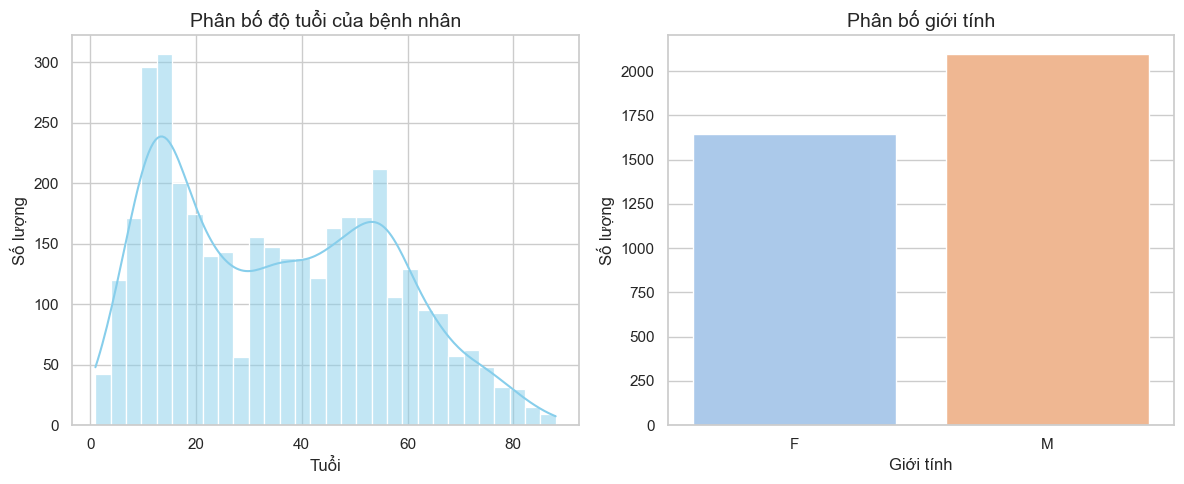

In [5]:
print("\n" + "="*50)
print("2. THỐNG KÊ NHÂN KHẨU HỌC")
print("="*50)
print("Thống kê mô tả độ tuổi:")
print(df['age'].describe())

print("\nPhân bố giới tính:")
print(df['gender'].value_counts())

# Cài đặt phong cách vẽ biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Biểu đồ 1: Phân bố độ tuổi
plt.subplot(1, 2, 1)
sns.histplot(df['age'].dropna(), kde=True, bins=30, color='skyblue')
plt.title('Phân bố độ tuổi của bệnh nhân', fontsize=14)
plt.xlabel('Tuổi')
plt.ylabel('Số lượng')

# Biểu đồ 2: Phân bố giới tính
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='gender', palette='pastel')
plt.title('Phân bố giới tính', fontsize=14)
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')

plt.tight_layout()
plt.show()

## Labels distribution


3. THỐNG KÊ MẪU CÓ U VÀ BÌNH THƯỜNG
Số liệu thống kê chi tiết:
Bình thường (Normal)    1879
Có U (Tumor)            1867
dtype: int64


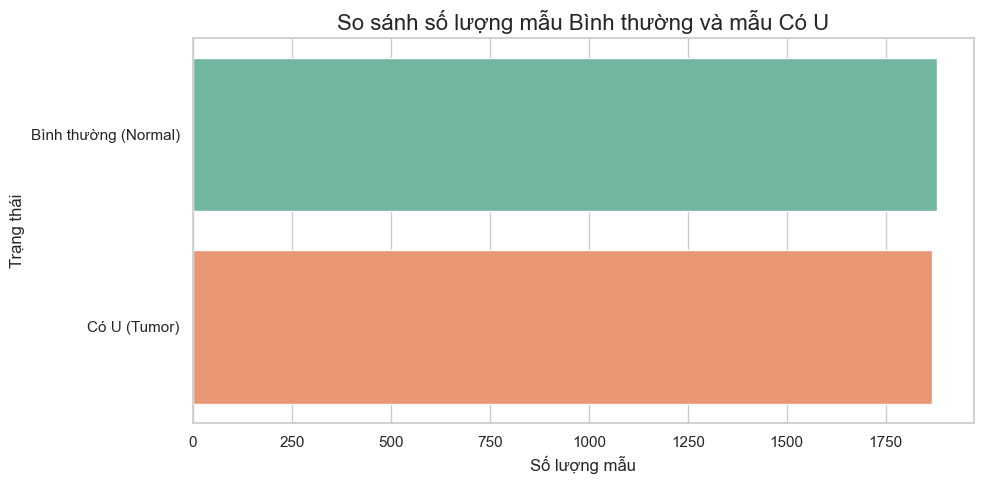

In [12]:
print("\n" + "="*50)
print("3. THỐNG KÊ MẪU CÓ U VÀ BÌNH THƯỜNG")
print("="*50)

# Tính toán số lượng mẫu Bình thường (tumor = 0) và Có U (tumor = 1)
normal_count = (df['tumor'] == 0).sum()
tumor_count = (df['tumor'] == 1).sum()

# Tạo một pandas Series để lưu trữ và hiển thị kết quả
disease_counts = pd.Series({
    'Bình thường (Normal)': normal_count,
    'Có U (Tumor)': tumor_count
})

print("Số liệu thống kê chi tiết:")
print(disease_counts)

# Biểu đồ 3: Trực quan hóa số lượng mẫu bình thường và có u
plt.figure(figsize=(10, 5))

# Dùng seaborn để vẽ barplot
sns.barplot(
    x=disease_counts.values, 
    y=disease_counts.index, 
    hue=disease_counts.index, 
    palette='Set2', 
    legend=False
)

plt.title('So sánh số lượng mẫu Bình thường và mẫu Có U', fontsize=16)
plt.xlabel('Số lượng mẫu', fontsize=12)
plt.ylabel('Trạng thái', fontsize=12)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()


3. THỐNG KÊ CÁC LOẠI U XƯƠNG
osteochondroma              754
osteosarcoma                297
multiple osteochondromas    263
simple bone cyst            206
other bt                    115
giant cell tumor             93
synovial osteochondroma      51
other mt                     45
osteofibroma                 44
dtype: int64


C:\Users\lebat\AppData\Local\Temp\ipykernel_35104\2039872381.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.values, y=disease_counts.index, palette='viridis')


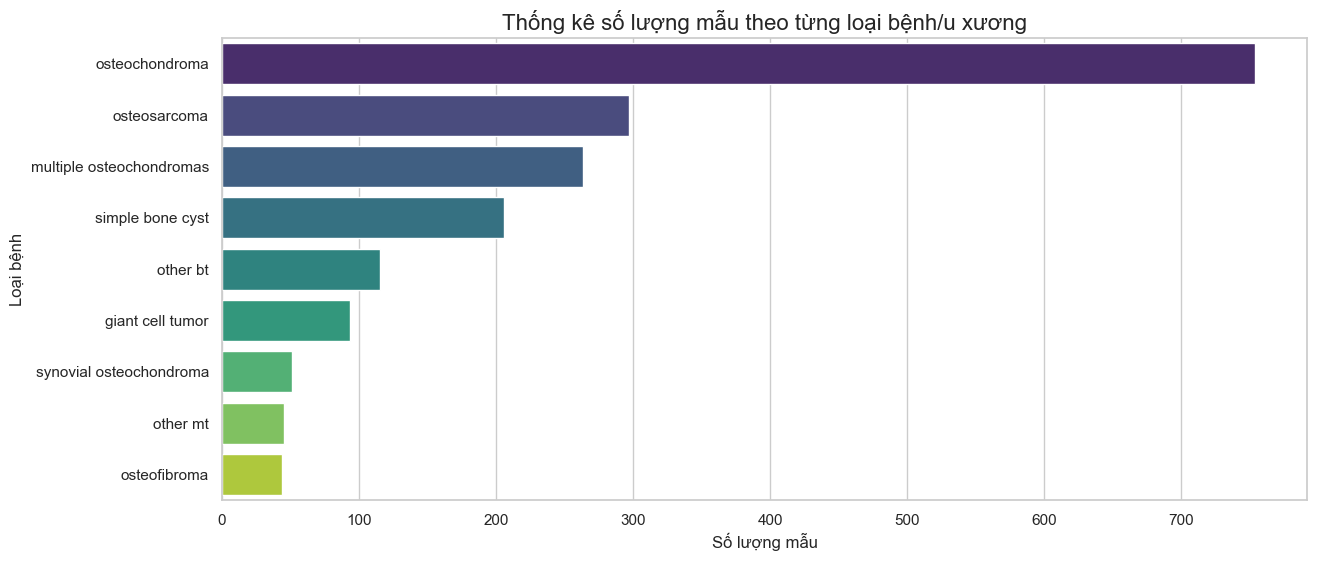

In [9]:
print("\n" + "="*50)
print("3. THỐNG KÊ CÁC LOẠI U XƯƠNG")
print("="*50)

# Danh sách các cột chứa nhãn bệnh lý
disease_cols = [
    'osteochondroma', 
    'multiple osteochondromas', 'simple bone cyst', 'giant cell tumor', 
    'osteofibroma', 'synovial osteochondroma', 'other bt', 
    'osteosarcoma', 'other mt'
]

# Tính tổng số ca dương tính (nhãn 1) cho mỗi bệnh
disease_counts = df[disease_cols].sum().sort_values(ascending=False)
print(disease_counts)

# Biểu đồ 3: Trực quan hóa số lượng các loại bệnh
plt.figure(figsize=(14, 6))
sns.barplot(x=disease_counts.values, y=disease_counts.index, palette='viridis')
plt.title('Thống kê số lượng mẫu theo từng loại bệnh/u xương', fontsize=16)
plt.xlabel('Số lượng mẫu', fontsize=12)
plt.ylabel('Loại bệnh', fontsize=12)
plt.show()


4. THỐNG KÊ VỊ TRÍ GIẢI PHẪU & GÓC CHỤP


C:\Users\lebat\AppData\Local\Temp\ipykernel_35104\2635401798.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=anatomy_counts.index, y=anatomy_counts.values, palette='magma')


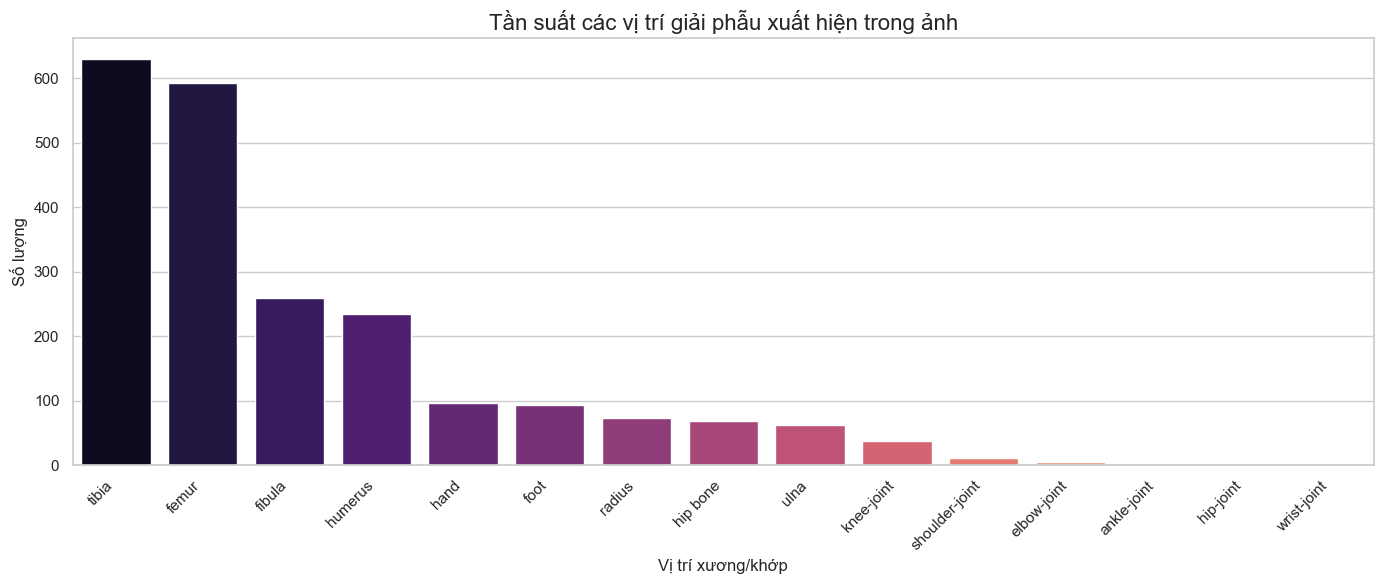

In [7]:
print("\n" + "="*50)
print("4. THỐNG KÊ VỊ TRÍ GIẢI PHẪU & GÓC CHỤP")
print("="*50)

# Phân tích vị trí (hand, ulna, radius,... femur, hip bone...)
anatomy_cols = [
    'hand', 'ulna', 'radius', 'humerus', 'foot', 'tibia', 
    'fibula', 'femur', 'hip bone', 'ankle-joint', 'knee-joint', 
    'hip-joint', 'wrist-joint', 'elbow-joint', 'shoulder-joint'
]
anatomy_counts = df[anatomy_cols].sum().sort_values(ascending=False)

# Phân tích góc chụp
view_cols = ['frontal', 'lateral', 'oblique']
view_counts = df[view_cols].sum()

# Vẽ biểu đồ vị trí giải phẫu
plt.figure(figsize=(14, 6))
sns.barplot(x=anatomy_counts.index, y=anatomy_counts.values, palette='magma')
plt.title('Tần suất các vị trí giải phẫu xuất hiện trong ảnh', fontsize=16)
plt.xlabel('Vị trí xương/khớp', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục x cho dễ nhìn
plt.tight_layout()
plt.show()

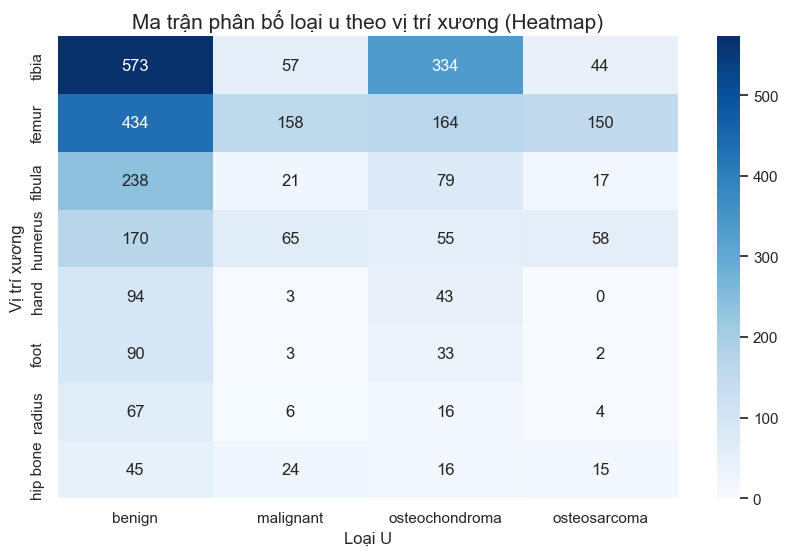

In [8]:
# Xem xét các bệnh ác tính/lành tính thường xuất hiện ở vị trí xương nào
# Lọc ra nhóm bệnh nhân có u (tumor == 1)
df_tumor = df[df['tumor'] == 1]

# Tính ma trận tương quan giữa vị trí và các loại u chính
cross_tab = pd.DataFrame()
main_tumor_types = ['benign', 'malignant', 'osteochondroma', 'osteosarcoma']
top_anatomy = anatomy_counts.head(8).index # Lấy 8 vị trí phổ biến nhất

for anatomy in top_anatomy:
    for tumor_type in main_tumor_types:
        # Đếm số ca có cùng lúc u loại này ở xương này
        count = df_tumor[(df_tumor[anatomy] == 1) & (df_tumor[tumor_type] == 1)].shape[0]
        cross_tab.loc[anatomy, tumor_type] = count

plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab, annot=True, fmt="g", cmap='Blues')
plt.title('Ma trận phân bố loại u theo vị trí xương (Heatmap)', fontsize=15)
plt.xlabel('Loại U')
plt.ylabel('Vị trí xương')
plt.show()